In [25]:
from qutip import *
from tdse_solutions import *
from scipy.special import genlaguerre, hyp1f1

In [39]:
def ion_ham_all_ord(f_arr, t_arr, eta, m_x, N_cutoff):
    n_range = np.arange(1, N_cutoff-1)

    A_diag = math.exp(-eta**2/2)/np.sqrt(n_range+1)*np.array([genlaguerre(n, 1)(eta**2) for n in n_range])
    #A_diag = math.exp(-eta**2/2)*np.sqrt(n_range+1)*np.array([hyp1f1(-n, 2, eta**2) for n in n_range])
    #A = -1j/eta*Qobj(np.diag(np.diag((1j*math.sqrt(2)*eta*position(N_cutoff)).expm().data.to_array(), k=1), k=1))
    A = Qobj(np.diag(A_diag, k=1))
    return QobjEvo([[A,        m_x*np.conj(f_arr)],
                    [A.dag(),  m_x*f_arr]], tlist=t_arr)


In [42]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 4001)

N_cutoff = 200
eta = 0.1

n_ions = 10
mx_arr = np.arange(-n_ions/2, n_ions/2+1)
f_max = 1/2
n_loops = 1

phase_arr = []
f_arr = f_max*np.exp(-1j*n_loops*t_arr)

In [48]:
n_range = np.arange(0, N_cutoff-1)

A_diag = math.exp(-eta**2/2)/np.sqrt(n_range+1)*np.array([genlaguerre(n, 1)(eta**2) for n in n_range])
A_diag = math.exp(-eta**2/2)*np.sqrt(n_range+1)*np.array([hyp1f1(-n, 2, eta**2) for n in n_range])
#A = -1j/eta*Qobj(np.diag(np.diag((1j*math.sqrt(2)*eta*position(N_cutoff)).expm().data.to_array(), k=1), k=1))
A = Qobj(scipy.sparse.diags(A_diag, offsets=1))
A

Quantum object: dims=[[200], [200]], shape=(200, 200), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         0.99501248 0.         ... 0.         0.         0.        ]
 [0.         0.         1.40012434 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         4.04966238 0.        ]
 [0.         0.         0.         ... 0.         0.         4.02584453]
 [0.         0.         0.         ... 0.         0.         0.        ]]

In [45]:
create(300)

Quantum object: dims=[[300], [300]], shape=(300, 300), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 1.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          1.41421356  0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... 17.2626765   0.
   0.        ]
 [ 0.          0.          0.         ...  0.         17.29161647
   0.        ]]

In [44]:
n_range = np.arange(0, N_cutoff-1)

#A_diag = math.exp(-eta**2/2)/np.sqrt(n_range+1)*np.array([genlaguerre(n, 1)(eta**2) for n in n_range])
A_diag = math.exp(-eta**2/2)*np.sqrt(n_range+1)*np.array([hyp1f1(-n, 2, eta**2) for n in n_range])
#A = -1j/eta*Qobj(np.diag(np.diag((1j*math.sqrt(2)*eta*position(N_cutoff)).expm().data.to_array(), k=1), k=1))
A = Qobj(np.diag(A_diag, k=1))
A

Quantum object: dims=[[200], [200]], shape=(200, 200), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.         0.99501248 0.         ... 0.         0.         0.        ]
 [0.         0.         1.40012434 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         4.04966238 0.        ]
 [0.         0.         0.         ... 0.         0.         4.02584453]
 [0.         0.         0.         ... 0.         0.         0.        ]]

In [33]:
#N_cutoff = get_coherent_cutoff(alpha_est, 1e-7)
psi0 = fock(N_cutoff, 0)
for mx in mx_arr:
    ham = ion_ham_all_ord(f_arr, t_arr, eta, mx, N_cutoff)
    result = sesolve(ham, psi0, t_arr, options={'store_states'     : False,
                                                'store_final_state': True})
    phase = result.final_state[0,0]*np.exp(1j*np.pi/2*mx**2)
    phase_arr.append(phase)

phase_arr = np.array(phase_arr)

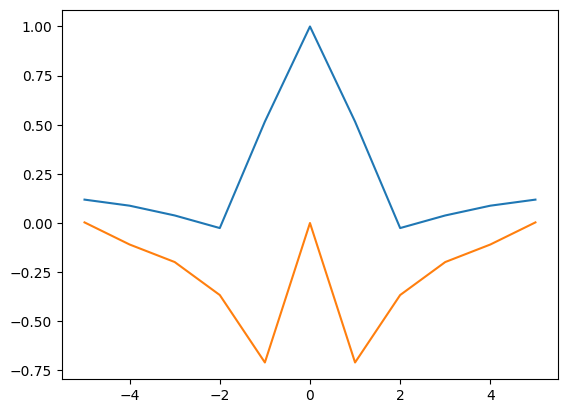

In [34]:
plt.plot(mx_arr, phase_arr.real)
plt.plot(mx_arr, phase_arr.imag)

In [8]:
A = -1j/eta*Qobj(np.diag(np.diag((1j*eta*math.sqrt(2)*position(N_cutoff)).expm().data.to_array(), k=1), k=1))
#np.diag(A.data.to_array(), k=1)

In [23]:
eta = 0.03

In [38]:
for n in range(600):
    print(genlaguerre(n, 1)(eta**2))
    #print((n+1)*hyp1f1(-n, 2, eta**2))

1.0
1.9990999999999999
2.9973004050000003
3.9946016198785004
4.991004049392528
5.986508098177665
6.981114170748075
7.974822671496532
8.967634004694444
9.959548574491889
10.950566784917628
11.940689039879146
12.929915743162676
13.918247298433215
14.90568410923457
15.892226578989371
16.877875110999106
17.862630108444137
18.846491974383746
19.82946111175615
20.811537923378523
21.79272281194704
22.773016180036883
23.752418430102292
24.730929964476573
25.70855118537213
26.6852824948805
27.661124294972378
28.636076987497628
29.610140974185338
30.583316656643824
31.555604436360664
32.52700471470273
33.497517892916214
34.467144372126654
35.435884553338944
36.40373883743741
37.37070762518577
38.336791317227224
39.30199031408443
40.26630501615957
41.22973582373435
42.192283136970055
43.15394735590755
44.1147288804673
45.074628110449446
46.03364544553378
46.99178128527979
47.9490360291267
48.905410076393494
49.8609038262789
50.8155176778615
51.76925203009967
52.722107281831676
53.67408383177564
5

In [13]:
math.exp(-eta**2/2)/np.sqrt(n_range+1)*np.array([genlaguerre(n, 1)(eta**2) for n in n_range])

/home/evgeny/pyenvs/quantum_env/lib/python3.14/site-packages/scipy/special/_orthogonal.py:667: RuntimeWarning: invalid value encountered in scalar divide
  hn = _gam(n + alpha + 1) / _gam(n + 1)
/home/evgeny/pyenvs/quantum_env/lib/python3.14/site-packages/scipy/special/_orthogonal.py:133: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/home/evgeny/pyenvs/quantum_env/lib/python3.14/site-packages/scipy/special/_orthogonal.py:119: RuntimeWarning: divide by zero encountered in scalar divide
  equiv_weights = [weights[k] / wfunc(roots[k]) for
/home/evgeny/pyenvs/quantum_env/lib/python3.14/site-packages/scipy/special/_orthogonal.py:119: RuntimeWarning: invalid value encountered in scalar divide
  equiv_weights = [weights[k] / wfunc(roots[k]) for


array([ 1.41407215,  1.73179101,  1.99960003,  2.23550901,  2.44875497,
        2.64482541,  2.82729591,  2.9986502 ,  3.16069679,  3.31480098,
        3.46202357,  3.60320818,  3.73903884,  3.87007934,  3.99680085,
        4.11960198,  4.23882346,  4.3547593 ,  4.46766531,  4.57776568,
        4.6852582 ,  4.79031843,  4.89310306,  4.99375261,  5.09239366,
        5.18914078,  5.28409798,  5.37736009,  5.46901385,  5.55913879,
        5.64780811,  5.73508933,  5.82104489,  5.90573268,  5.98920648,
        6.07151636,  6.15270903,  6.23282817,  6.31191464,  6.3900068 ,
        6.46714067,  6.54335013,  6.61866713,  6.69312179,  6.76674258,
        6.83955643,  6.91158884,  6.982864  ,  7.05340487,  7.12323326,
        7.19236993,  7.26083464,  7.32864621,  7.39582263,  7.46238104,
        7.52833784,  7.59370871,  7.65850864,  7.72275202,  7.78645262,
        7.84962366,  7.91227783,  7.9744273 ,  8.03608378,  8.09725856,
        8.15796245,  8.21820589,  8.27799895,  8.33735131,  8.39

In [9]:
genlaguerre(400, 1)

/home/evgeny/pyenvs/quantum_env/lib/python3.14/site-packages/scipy/special/_orthogonal.py:568: RuntimeWarning: overflow encountered in multiply
  - (n + alpha) * _ufuncs.eval_genlaguerre(n - 1, alpha, x)) / x


poly1d([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, n

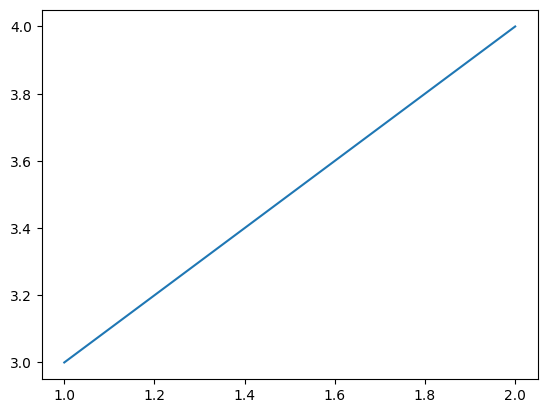

In [1]:
fig, ax = plt.subplots(1, 1)

ax.plot([1,2],[3,4])

In [4]:
dir(ax.xaxis)

['OFFSETTEXTPAD',
 '_PROPERTIES_EXCLUDED_FROM_SET',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_agg_filter',
 '_alpha',
 '_animated',
 '_autolabelpos',
 '_autoscale_on',
 '_axes',
 '_callbacks',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_converter',
 '_converter_is_explicit',
 '_copy_tick_props',
 '_different_canvas',
 '_format_with_dict',
 '_fully_clipped_to_axes',
 '_get_autoscale_on',
 '_get_axis_name',
 '_get_shared_axes',
 '_get_shared_axis',
 '_get_tick',
 '_get_tick_boxes_siblings',
 '_get_tick_label_size',
 '_get_ticklabel_bboxes',
 '_get_ticks_position',
 '_gid',
 '_in_layout',
 '_

In [5]:
ax.get_xlim()

(np.float64(0.95), np.float64(2.05))